# Projet ML - Immobilier Paris (Pipeline Scikit-Learn + Modélisation)

Ce notebook couvre la section **4. Pipeline ML** du projet.

## Objectif
Construire un **pipeline Scikit-Learn complet** avec :
- Séparation Train/Test stricte (80/20) **AVANT** toute transformation
- ColumnTransformer pour variables numériques (imputation + normalisation)
- OneHotEncoder pour variables catégorielles
- Intégration avec des modèles de régression

## Imports et Configuration

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: preprocessing et pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Chargement et Nettoyage des Données

In [2]:
# Téléchargement direct de DVF Paris
DATA_DIR = Path('data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

url_candidates = [
    'https://files.data.gouv.fr/geo-dvf/latest/csv/2022/departements/75.csv.gz',
    'https://files.data.gouv.fr/geo-dvf/latest/csv/2021/departements/75.csv.gz'
]

df_raw = None
for url in url_candidates:
    try:
        df_raw = pd.read_csv(url, compression='gzip', low_memory=False)
        if len(df_raw) > 0:
            break
    except Exception as e:
        print(f'URL indisponible: {url}')

if df_raw is None:
    raise RuntimeError('Impossible de charger les données DVF Paris')

print(f'Dimensions initiales: {df_raw.shape}')

Dimensions initiales: (98308, 40)


In [3]:
# Nettoyage: même processus que dans l'EDA
df = df_raw.copy()

# Typage
df['date_mutation'] = pd.to_datetime(df['date_mutation'], errors='coerce')

# Variables numériques
for col in ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Filtrage business: ventes d'appartements à Paris
df = df[df['nature_mutation'].str.lower().eq('vente')]
df = df[df['type_local'].str.lower().eq('appartement')]
df = df[df['nom_commune'].str.upper().str.startswith('PARIS')]

# Variables dérivées
df = df[df['surface_reelle_bati'] > 0]
df = df[df['valeur_fonciere'] > 0]
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']

# Arrondissement
df['code_postal'] = pd.to_numeric(df['code_postal'], errors='coerce')
df['arrondissement'] = (df['code_postal'] - 75000).astype('Int64')

# Suppression des outliers extrêmes (1%-99%)
q_low, q_high = df['prix_m2'].quantile([0.01, 0.99])
df = df[(df['prix_m2'] >= q_low) & (df['prix_m2'] <= q_high)]

print(f'Dimensions après nettoyage: {df.shape}')
print(f'\nValeurs manquantes (%):')
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0].head(10))

Dimensions après nettoyage: (41624, 42)

Valeurs manquantes (%):
ancien_nom_commune              100.000000
nature_culture_speciale         100.000000
numero_volume                   100.000000
ancien_id_parcelle              100.000000
ancien_code_commune             100.000000
code_nature_culture_speciale    100.000000
lot5_surface_carrez              99.913511
lot4_surface_carrez              99.632424
lot5_numero                      98.976552
lot3_surface_carrez              98.633000
dtype: float64


## Préparation des Features pour le Pipeline

In [4]:
# Sélection des features pour la modélisation

# Variables numériques
numeric_features = ['surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']

# Variables catégorielles
categorical_features = ['nom_commune', 'arrondissement']

# Cible
target = 'prix_m2'

# Sélection du sous-ensemble
features = numeric_features + categorical_features
df_clean = df[features + [target]].dropna()

df_clean[categorical_features] = df_clean[categorical_features].astype(str)

print(f'Dataset complet après suppression des NaNs: {df_clean.shape}')
print(f'\nFeatures numériques: {numeric_features}')
print(f'Features catégorielles: {categorical_features}')
print(f'\nCible: {target}')
print(f'\nTypes des variables:')
print(df_clean[features].dtypes)
print(f'\nStatistiques de la cible:')
print(df_clean[target].describe())

Dataset complet après suppression des NaNs: (41526, 7)

Features numériques: ['surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']
Features catégorielles: ['nom_commune', 'arrondissement']

Cible: prix_m2

Types des variables:
surface_reelle_bati          float64
nombre_pieces_principales    float64
longitude                    float64
latitude                     float64
nom_commune                      str
arrondissement                   str
dtype: object

Statistiques de la cible:
count    4.152600e+04
mean     2.990081e+04
std      8.748043e+04
min      5.769231e+01
25%      9.421345e+03
50%      1.115942e+04
75%      1.388889e+04
max      1.045761e+06
Name: prix_m2, dtype: float64


## SÉPARATION TRAIN/TEST STRICTE (80/20)

In [5]:
# Séparer AVANT toute transformation pour éviter les fuites de données
X = df_clean[features].copy()
y = df_clean[target].copy()

# Assurer que les variables catégorielles sont en string
X[categorical_features] = X[categorical_features].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% test, 80% train
    random_state=42     # reproducibilité
)

print(f'Dimensions Train:')
print(f'  X_train: {X_train.shape}')
print(f'  y_train: {y_train.shape}')
print(f'\nDimensions Test:')
print(f'  X_test: {X_test.shape}')
print(f'  y_test: {y_test.shape}')
print(f'\nRatio test/total: {len(X_test) / (len(X_train) + len(X_test)):.1%}')
print(f'\nVérification des types (train):')
print(X_train.dtypes)

Dimensions Train:
  X_train: (33220, 6)
  y_train: (33220,)

Dimensions Test:
  X_test: (8306, 6)
  y_test: (8306,)

Ratio test/total: 20.0%

Vérification des types (train):
surface_reelle_bati          float64
nombre_pieces_principales    float64
longitude                    float64
latitude                     float64
nom_commune                      str
arrondissement                   str
dtype: object


## Construction du ColumnTransformer

In [6]:
# Transformateur pour variables NUMÉRIQUES
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputation par la médiane
    ('scaler', StandardScaler())                    # Normalisation (moyenne=0, écart-type=1)
])

# Transformateur pour variables CATÉGORIELLES
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Imputation constante
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # OneHotEncoding
])

# ColumnTransformer: applique les transformations appropriées à chaque groupe
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print('✓ ColumnTransformer créé avec succès')
print(f'\nVariables numériques ({len(numeric_features)}): {numeric_features}')
print(f'Variables catégorielles ({len(categorical_features)}): {categorical_features}')

✓ ColumnTransformer créé avec succès

Variables numériques (4): ['surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']
Variables catégorielles (2): ['nom_commune', 'arrondissement']


## Fit et Transform sur les données TRAIN

In [7]:
# Cela calcule la médiane, l'écart-type, et les catégories UNIQUES à partir du train
X_train_transformed = preprocessor.fit_transform(X_train)

print(f'X_train_transformed shape: {X_train_transformed.shape}')
print(f'Type: {type(X_train_transformed)}')
print(f'\nPremières lignes transformées (train):')
print(X_train_transformed[:3])

X_train_transformed shape: (33220, 44)
Type: <class 'numpy.ndarray'>

Premières lignes transformées (train):
[[-0.78009358 -0.31819367 -0.46425976  1.15128476  0.          0.
   0.          0.          0.          0.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 2.28135142  1.97738917 -1.1213739   0.87169619  0.          0.
   0.          0.          0.          0.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   0. 

In [8]:
# Transform X_test avec les paramètres appris sur le train
X_test_transformed = preprocessor.transform(X_test)

print(f'X_test_transformed shape: {X_test_transformed.shape}')
print(f'\nPremières lignes transformées (test):')
print(X_test_transformed[:3])

# Vérification: pas de NaN après transformation
print(f'\nNaNs dans X_train_transformed: {np.isnan(X_train_transformed).sum()}')
print(f'NaNs dans X_test_transformed: {np.isnan(X_test_transformed).sum()}')

X_test_transformed shape: (8306, 44)

Premières lignes transformées (test):
[[-0.18273846 -0.31819367  1.08516542  0.00443511  0.          1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-0.45652622 -1.08338795  0.19666172 -0.13925641  0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          

## Pipeline Complet: Preprocessor + Modèle

In [9]:
# Pipeline = ColumnTransformer + Modèle de régression
# Cela encapsule tout le workflow: preprocessing + modèle

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Fit sur les données TRAIN
pipeline_lr.fit(X_train, y_train)

# Prédictions
y_train_pred = pipeline_lr.predict(X_train)
y_test_pred = pipeline_lr.predict(X_test)

# Évaluation
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print('═' * 60)
print('RÉGRESSION LINÉAIRE - RÉSULTATS')
print('═' * 60)
print(f'\nTRAIN:')
print(f'  RMSE: {train_rmse:,.0f} €/m²')
print(f'  MAE:  {train_mae:,.0f} €/m²')
print(f'  R²:   {train_r2:.4f}')
print(f'\nTEST:')
print(f'  RMSE: {test_rmse:,.0f} €/m²')
print(f'  MAE:  {test_mae:,.0f} €/m²')
print(f'  R²:   {test_r2:.4f}')
print(f'\nSurfit (RMSE_test - RMSE_train): {test_rmse - train_rmse:,.0f} €/m²')

════════════════════════════════════════════════════════════
RÉGRESSION LINÉAIRE - RÉSULTATS
════════════════════════════════════════════════════════════

TRAIN:
  RMSE: 86,992 €/m²
  MAE:  33,234 €/m²
  R²:   0.0155

TEST:
  RMSE: 85,940 €/m²
  MAE:  33,611 €/m²
  R²:   0.0173

Surfit (RMSE_test - RMSE_train): -1,052 €/m²


## Comparaison de Modèles

In [10]:
# Définir plusieurs modèles avec le même preprocessing
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1)': Ridge(alpha=1.0),
    'Ridge (α=100)': Ridge(alpha=100.0),
    'Random Forest (n=50)': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    # Créer un pipeline avec le modèle actuel
    pipe = Pipeline(steps=[
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features),
                ('cat', categorical_transformer, categorical_features)
            ]
        )),
        ('model', model)
    ])
    
    # Fit et prédiction
    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    # Métriques
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results.append({
        'Modèle': name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Surfit': test_rmse - train_rmse,
        'Train R²': train_r2,
        'Test R²': test_r2
    })

results_df = pd.DataFrame(results)
print('\n' + '═' * 100)
print('COMPARAISON DES MODÈLES')
print('═' * 100)
display(results_df.style.format({
    'Train RMSE': '{:,.0f}',
    'Test RMSE': '{:,.0f}',
    'Surfit': '{:,.0f}',
    'Train R²': '{:.4f}',
    'Test R²': '{:.4f}'
}))


════════════════════════════════════════════════════════════════════════════════════════════════════
COMPARAISON DES MODÈLES
════════════════════════════════════════════════════════════════════════════════════════════════════


,Modèle,Train RMSE,Test RMSE,Surfit,Train R²,Test R²
0,Linear Regression,"86,992","85,940","-1,052",0.0155,0.0173
1,Ridge (α=1),"86,992","85,940","-1,052",0.0155,0.0173
2,Ridge (α=100),"87,001","85,951","-1,050",0.0153,0.0171
3,Random Forest (n=50),"15,328","35,565","20,237",0.9694,0.8317


## Analyse des Résidus

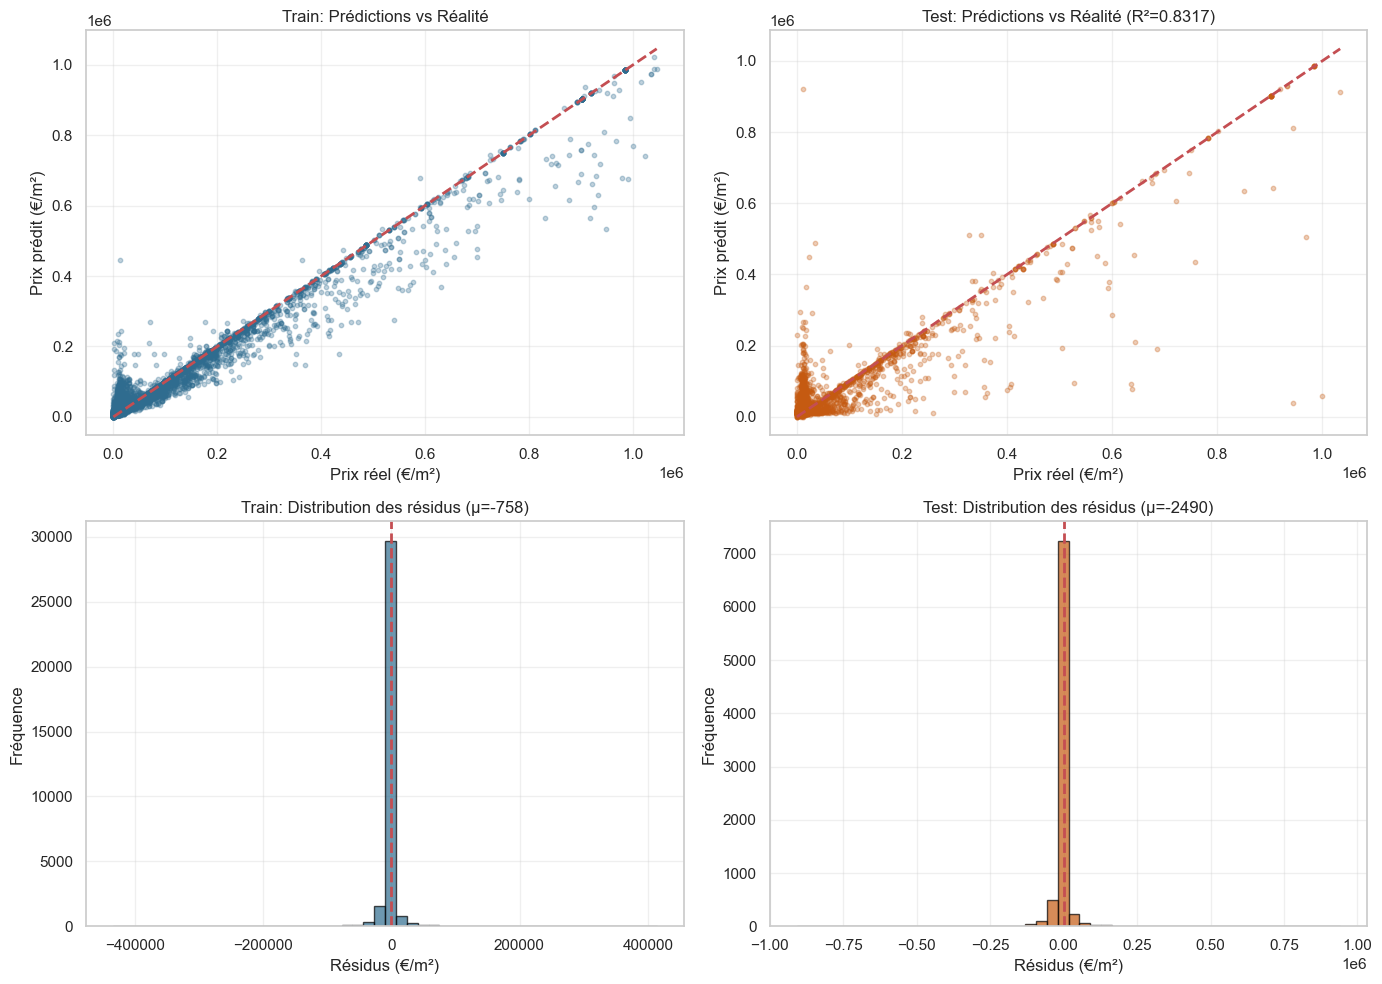

In [11]:
# Résidus du modèle Linear Regression
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Prédictions vs Réalité (Train)
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.3, s=10, color='#2f6c8f')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Prix réel (€/m²)')
axes[0, 0].set_ylabel('Prix prédit (€/m²)')
axes[0, 0].set_title('Train: Prédictions vs Réalité')
axes[0, 0].grid(alpha=0.3)

# Prédictions vs Réalité (Test)
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='#c55a11')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Prix réel (€/m²)')
axes[0, 1].set_ylabel('Prix prédit (€/m²)')
axes[0, 1].set_title(f'Test: Prédictions vs Réalité (R²={test_r2:.4f})')
axes[0, 1].grid(alpha=0.3)

# Distribution des résidus (Train)
axes[1, 0].hist(residuals_train, bins=50, color='#2f6c8f', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Résidus (€/m²)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title(f'Train: Distribution des résidus (μ={residuals_train.mean():.0f})')
axes[1, 0].grid(alpha=0.3)

# Distribution des résidus (Test)
axes[1, 1].hist(residuals_test, bins=50, color='#c55a11', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Résidus (€/m²)')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].set_title(f'Test: Distribution des résidus (μ={residuals_test.mean():.0f})')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Importance des Features (Random Forest)


Top 10 Features (Random Forest):
                             Feature  Importance
                            latitude    0.520105
                           longitude    0.351191
                 surface_reelle_bati    0.079084
           nombre_pieces_principales    0.021699
nom_commune_Paris 17e Arrondissement    0.001806
                    arrondissement_8    0.001605
 nom_commune_Paris 8e Arrondissement    0.001540
                    arrondissement_3    0.001258
                   arrondissement_17    0.001135
                    arrondissement_4    0.001087


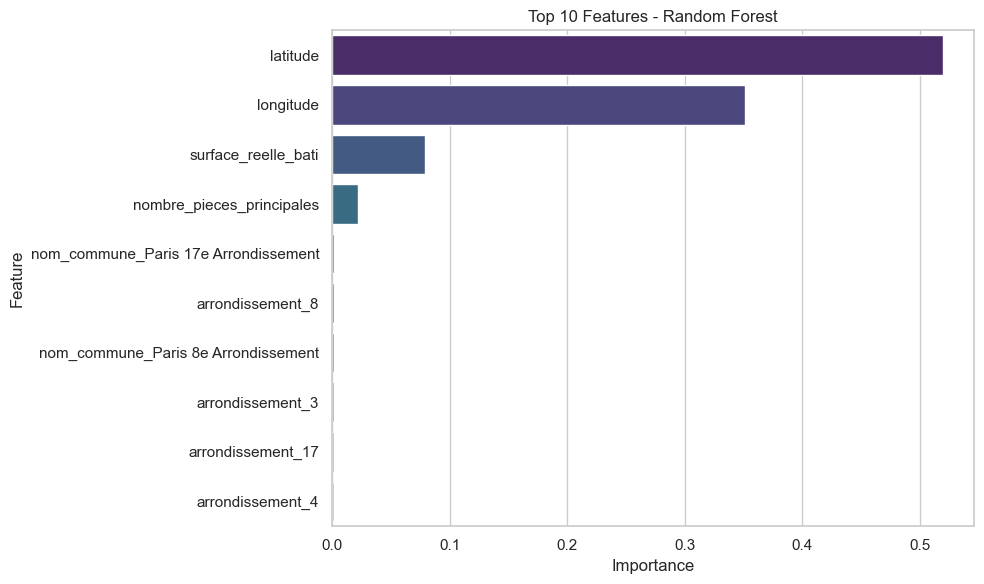

In [12]:
# Créer et fit un Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline_rf.fit(X_train, y_train)

# Extraire l'importance des features
feature_importances = pipeline_rf.named_steps['model'].feature_importances_

# On récupère les noms du ColumnTransformer
feature_names = []

# Features numériques (non transformées)
feature_names.extend(numeric_features)

# Features catégorielles (après OneHot)
onehot_encoder = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = onehot_encoder.get_feature_names_out(categorical_features).tolist()
feature_names.extend(cat_feature_names)

# DataFrame d'importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Afficher top 10
print('\nTop 10 Features (Random Forest):')
print(importance_df.head(10).to_string(index=False))

# Visualiser
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

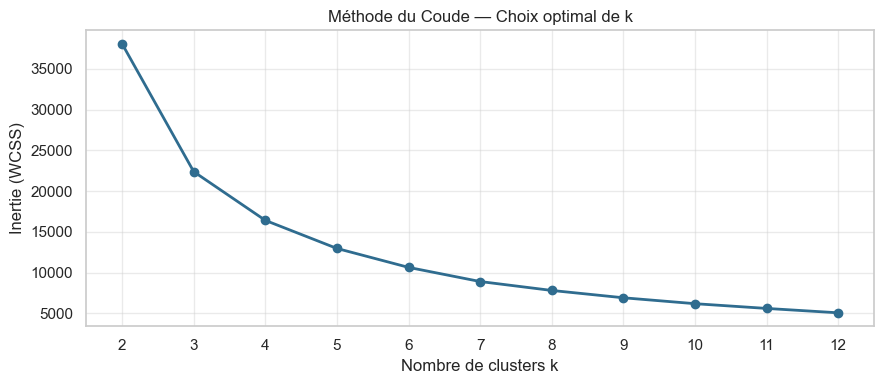

✓ cluster_quartier créé | k=6
Clusters: ['0', '1', '2', '3', '4', '5']

Distribution (train):
cluster_quartier
0    7441
1    5396
2    3696
3    6983
4    5476
5    4228
Name: count, dtype: int64

Prix médian par cluster (€/m²):
cluster_quartier
2    12934.198718
4    11600.000000
1    11200.000000
0    10857.142857
3    10857.142857
5    10431.935152
Name: prix_m2, dtype: float64


In [13]:
from sklearn.cluster import KMeans

geo_cols = ['longitude', 'latitude']

geo_scaler = StandardScaler()
X_train_geo = geo_scaler.fit_transform(X_train[geo_cols])
X_test_geo  = geo_scaler.transform(X_test[geo_cols])

# ─── Méthode du Coude ───
inertias = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_geo)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, marker='o', color='#2f6c8f', linewidth=2)
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (WCSS)')
plt.title('Méthode du Coude — Choix optimal de k')
plt.xticks(K_range)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# ─── Entraînement K-Means avec k optimal ───
# Modifie K_OPTIMAL après avoir observé le coude ci-dessus
K_OPTIMAL = 6

kmeans_geo = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20)
kmeans_geo.fit(X_train_geo)  # ⚠️ fit sur train uniquement

# Ajout de 'cluster_quartier' — predict sur train ET test (pas fit_predict)
X_train['cluster_quartier'] = kmeans_geo.predict(X_train_geo).astype(str)
X_test['cluster_quartier']  = kmeans_geo.predict(X_test_geo).astype(str)

print(f'✓ cluster_quartier créé | k={K_OPTIMAL}')
print(f'Clusters: {sorted(X_train["cluster_quartier"].unique())}')
print(f'\nDistribution (train):')
print(X_train['cluster_quartier'].value_counts().sort_index())

cluster_prix = (
    pd.concat([X_train[['cluster_quartier']], y_train], axis=1)
      .groupby('cluster_quartier')['prix_m2']
      .median()
      .sort_values(ascending=False)
)
print(f'\nPrix médian par cluster (€/m²):')
print(cluster_prix)

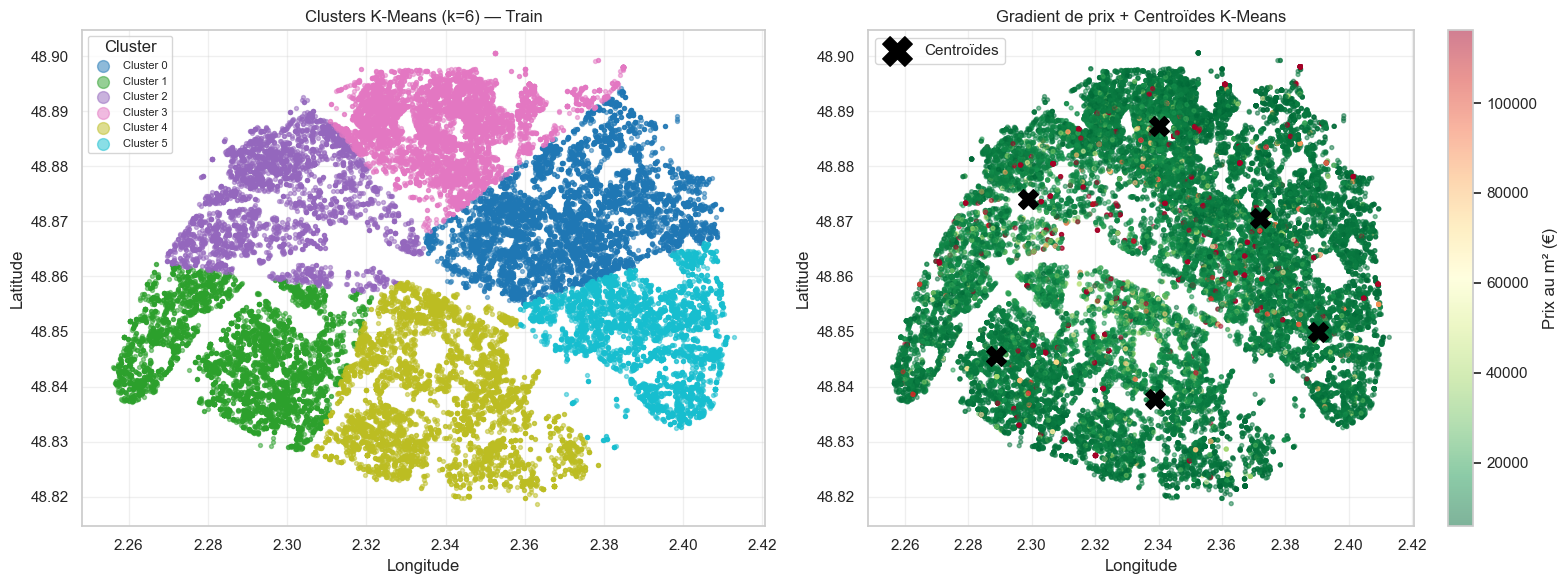

In [14]:
# ─── Scatter Plot des Clusters sur Paris ───
palette = plt.cm.get_cmap('tab10', K_OPTIMAL)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gauche: clusters colorés
for cluster_id in sorted(X_train['cluster_quartier'].unique()):
    mask = X_train['cluster_quartier'] == cluster_id
    axes[0].scatter(
        X_train.loc[mask, 'longitude'],
        X_train.loc[mask, 'latitude'],
        s=8, alpha=0.5, label=f'Cluster {cluster_id}',
        color=palette(int(cluster_id))
    )
axes[0].set_title(f'Clusters K-Means (k={K_OPTIMAL}) — Train')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(title='Cluster', markerscale=3, fontsize=8)
axes[0].grid(alpha=0.3)

# Droite: gradient de prix + centroïdes
X_train_plot = X_train.copy()
X_train_plot['prix_m2'] = y_train.values

scatter = axes[1].scatter(
    X_train_plot['longitude'],
    X_train_plot['latitude'],
    c=X_train_plot['prix_m2'],
    cmap='RdYlGn_r', s=8, alpha=0.5,
    vmin=y_train.quantile(0.05),
    vmax=y_train.quantile(0.95)
)
centroids_geo = geo_scaler.inverse_transform(kmeans_geo.cluster_centers_)
axes[1].scatter(centroids_geo[:, 0], centroids_geo[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroïdes')
plt.colorbar(scatter, ax=axes[1], label='Prix au m² (€)')
axes[1].set_title('Gradient de prix + Centroïdes K-Means')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(markerscale=1.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ═════════════════════════════════════════════════════════════════════════════════════════════
# COMPARAISON V1 (sans cluster) vs V2 (avec cluster) — CELLULE COMPLÈTE ET INDÉPENDANTE
# ═════════════════════════════════════════════════════════════════════════════════════════════

# Step 1: Créer cluster_quartier s'il n'existe pas
if 'cluster_quartier' not in X_train.columns:
    print("⏳ Création de cluster_quartier...")
    geo_scaler_tmp = StandardScaler()
    X_train_geo_tmp = geo_scaler_tmp.fit_transform(X_train[['longitude', 'latitude']])
    X_test_geo_tmp = geo_scaler_tmp.transform(X_test[['longitude', 'latitude']])
    
    kmeans_tmp = KMeans(n_clusters=6, random_state=42, n_init=20)
    kmeans_tmp.fit(X_train_geo_tmp)
    
    X_train['cluster_quartier'] = kmeans_tmp.predict(X_train_geo_tmp).astype(str)
    X_test['cluster_quartier'] = kmeans_tmp.predict(X_test_geo_tmp).astype(str)
    print("✓ cluster_quartier créé")

# Step 2: Définir les features
numeric_features_v1      = ['surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']
categorical_features_v1  = ['nom_commune', 'arrondissement']

numeric_features_v2      = ['surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']
categorical_features_v2  = ['nom_commune', 'arrondissement', 'cluster_quartier']

# Step 3: Créer les subsets
X_train_v1 = X_train[numeric_features_v1 + categorical_features_v1]
X_test_v1  = X_test[numeric_features_v1 + categorical_features_v1]

X_train_v2 = X_train[numeric_features_v2 + categorical_features_v2]
X_test_v2  = X_test[numeric_features_v2 + categorical_features_v2]

# Step 4: Entraîner RF V1
numeric_trans_v1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_trans_v1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipe_rf_v1 = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', numeric_trans_v1, numeric_features_v1),
        ('cat', categorical_trans_v1, categorical_features_v1)
    ])),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_rf_v1.fit(X_train_v1, y_train)
y_pred_v1 = pipe_rf_v1.predict(X_test_v1)

# Step 5: Entraîner RF V2
numeric_trans_v2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_trans_v2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipe_rf_v2 = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', numeric_trans_v2, numeric_features_v2),
        ('cat', categorical_trans_v2, categorical_features_v2)
    ])),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_rf_v2.fit(X_train_v2, y_train)
y_pred_v2 = pipe_rf_v2.predict(X_test_v2)

# Step 6: Afficher les résultats
def calc_metrics(y_true, y_pred):
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }

metrics_v1 = calc_metrics(y_test, y_pred_v1)
metrics_v2 = calc_metrics(y_test, y_pred_v2)

print('\n' + '═' * 100)
print('IMPACT DE cluster_quartier — Random Forest')
print('═' * 100)
print(f'RF sans cluster_quartier')
print(f'  RMSE: {metrics_v1["rmse"]:>7,.0f} €/m²  |  MAE: {metrics_v1["mae"]:>7,.0f} €/m²  |  R²: {metrics_v1["r2"]:.4f}')
print(f'\nRF avec cluster_quartier (k=6)')
print(f'  RMSE: {metrics_v2["rmse"]:>7,.0f} €/m²  |  MAE: {metrics_v2["mae"]:>7,.0f} €/m²  |  R²: {metrics_v2["r2"]:.4f}')
print('═' * 100)

delta_rmse = metrics_v1['rmse'] - metrics_v2['rmse']
delta_r2 = metrics_v2['r2'] - metrics_v1['r2']
print(f'\n✓ Gain RMSE : {delta_rmse:+,.0f} €/m²  (positif = amélioration)')
print(f'✓ Gain R²   : {delta_r2:+.4f}')

if delta_rmse > 0:
    print(f'\ncluster_quartier améliore le modèle de {delta_rmse:,.0f} €/m² !')
else:
    print(f'\ncluster_quartier dégrade le modèle de {abs(delta_rmse):,.0f} €/m²')


════════════════════════════════════════════════════════════════════════════════════════════════════
IMPACT DE cluster_quartier — Random Forest
════════════════════════════════════════════════════════════════════════════════════════════════════
RF sans cluster_quartier
  RMSE:  34,907 €/m²  |  MAE:  10,993 €/m²  |  R²: 0.8379

RF avec cluster_quartier (k=6)
  RMSE:  34,736 €/m²  |  MAE:  10,932 €/m²  |  R²: 0.8395
════════════════════════════════════════════════════════════════════════════════════════════════════

✓ Gain RMSE : +171 €/m²  (positif = amélioration)
✓ Gain R²   : +0.0016

cluster_quartier améliore le modèle de 171 €/m² !


---
## Analyse et Interprétation du Modèle Random Forest

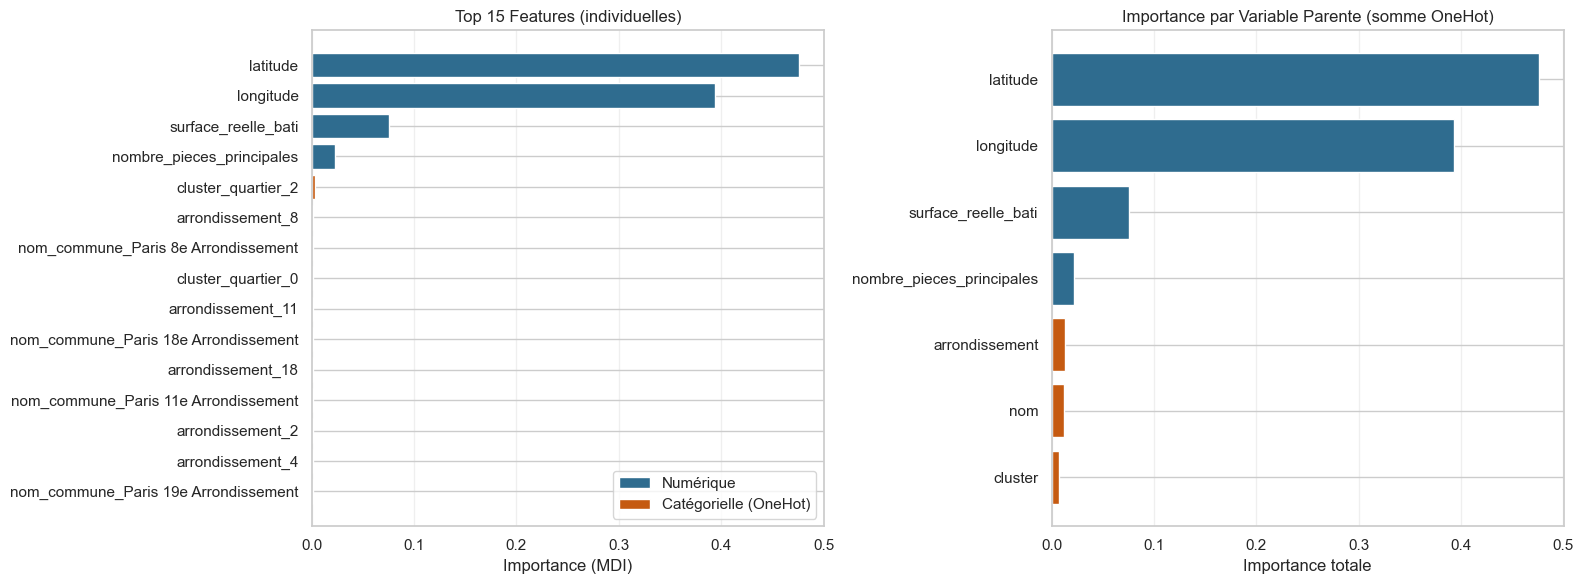

Importance par variable parente:
                    group  importance
                 latitude    0.476490
                longitude    0.393534
      surface_reelle_bati    0.075412
nombre_pieces_principales    0.022311
           arrondissement    0.012753
                      nom    0.012155
                  cluster    0.007346


In [16]:
# ─── Feature Importance ───
# Utilise pipe_rf_v2 (Random Forest avec cluster_quartier)
rf_model = pipe_rf_v2.named_steps['model']
ct       = pipe_rf_v2.named_steps['preprocessor']

# Noms des features: numériques + OneHot des catégorielles
num_names = numeric_features_v2.copy()
ohe       = ct.named_transformers_['cat'].named_steps['onehot']
cat_names = ohe.get_feature_names_out(categorical_features_v2).tolist()
all_names = num_names + cat_names

importance_df = (
    pd.DataFrame({'feature': all_names, 'importance': rf_model.feature_importances_})
      .sort_values('importance', ascending=False)
      .reset_index(drop=True)
)

# Regrouper les features OneHot par variable parente
importance_df['group'] = importance_df['feature'].apply(
    lambda x: x.split('_')[0] if any(x.startswith(c) for c in categorical_features_v2)
              else x
)
group_importance = (
    importance_df.groupby('group')['importance']
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe 1 : Top 15 features individuelles
top15 = importance_df.head(15)
colors = ['#2f6c8f' if f in numeric_features_v2 else '#c55a11' for f in top15['feature']]
axes[0].barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
axes[0].set_title('Top 15 Features (individuelles)')
axes[0].set_xlabel('Importance (MDI)')
axes[0].grid(axis='x', alpha=0.3)

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2f6c8f', label='Numérique'),
                   Patch(facecolor='#c55a11', label='Catégorielle (OneHot)')]
axes[0].legend(handles=legend_elements, loc='lower right')

# Graphe 2 : Importance par groupe (variable parente)
colors_group = ['#2f6c8f' if g in numeric_features_v2 else '#c55a11'
                for g in group_importance['group']]
axes[1].barh(group_importance['group'][::-1], group_importance['importance'][::-1],
             color=colors_group[::-1])
axes[1].set_title('Importance par Variable Parente (somme OneHot)')
axes[1].set_xlabel('Importance totale')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('Importance par variable parente:')
print(group_importance.to_string(index=False))

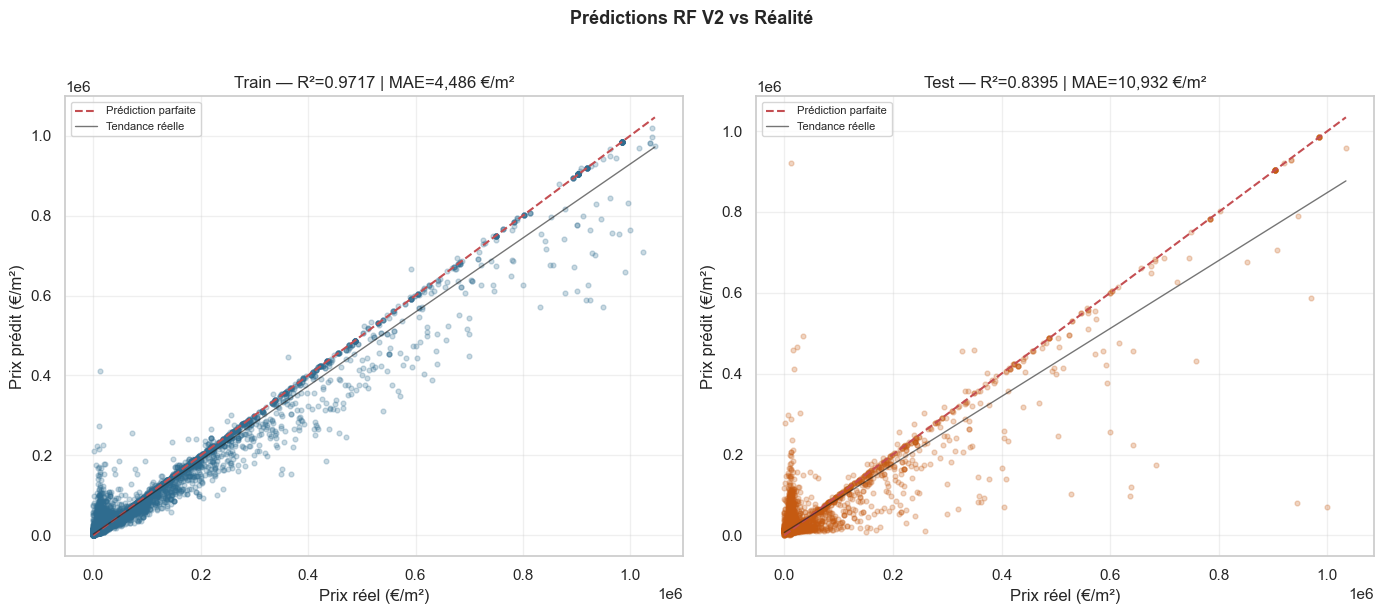

In [17]:
# ─── Corrélation Prédictions vs Réalité ───
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, label, color in [
    (axes[0], y_train, pipe_rf_v2.predict(X_train_v2), 'Train', '#2f6c8f'),
    (axes[1], y_test,  y_pred_v2,                      'Test',  '#c55a11'),
]:
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.25, s=12, color=color)

    # Droite parfaite y = x
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')

    # Droite de régression des résidus
    z = np.polyfit(y_true, y_pred, 1)
    p = np.poly1d(z)
    ax.plot(sorted(y_true), p(sorted(y_true)), 'k-', lw=1, alpha=0.6, label='Tendance réelle')

    ax.set_xlabel('Prix réel (€/m²)')
    ax.set_ylabel('Prix prédit (€/m²)')
    ax.set_title(f'{label} — R²={r2:.4f} | MAE={mae:,.0f} €/m²')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Prédictions RF V2 vs Réalité', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

══════════════════════════════════════════════════════════════════════════════════════════
TOP 5 PIRES PRÉDICTIONS — Analyse des Erreurs
══════════════════════════════════════════════════════════════════════════════════════════


,surface_reelle_bati,nombre_pieces_principales,nom_commune,arrondissement,cluster_quartier,prix_reel,prix_predit,erreur_abs,erreur_pct,sens
0,43 m²,2.000000,Paris 8e Arrondissement,8,2,"1,000,000 €/m²","71,151 €/m²","928,849 €/m²",92.9 %,Sous-estimation
1,67 m²,3.000000,Paris 14e Arrondissement,14,4,"12,022 €/m²","919,925 €/m²","907,904 €/m²",7552.2 %,Sur-estimation
2,9 m²,1.000000,Paris 20e Arrondissement,20,0,"944,444 €/m²","79,011 €/m²","865,434 €/m²",91.6 %,Sous-estimation
3,25 m²,2.000000,Paris 7e Arrondissement,7,1,"636,000 €/m²","96,343 €/m²","539,657 €/m²",84.9 %,Sous-estimation
4,80 m²,3.000000,Paris 8e Arrondissement,8,2,"637,500 €/m²","120,251 €/m²","517,249 €/m²",81.1 %,Sous-estimation


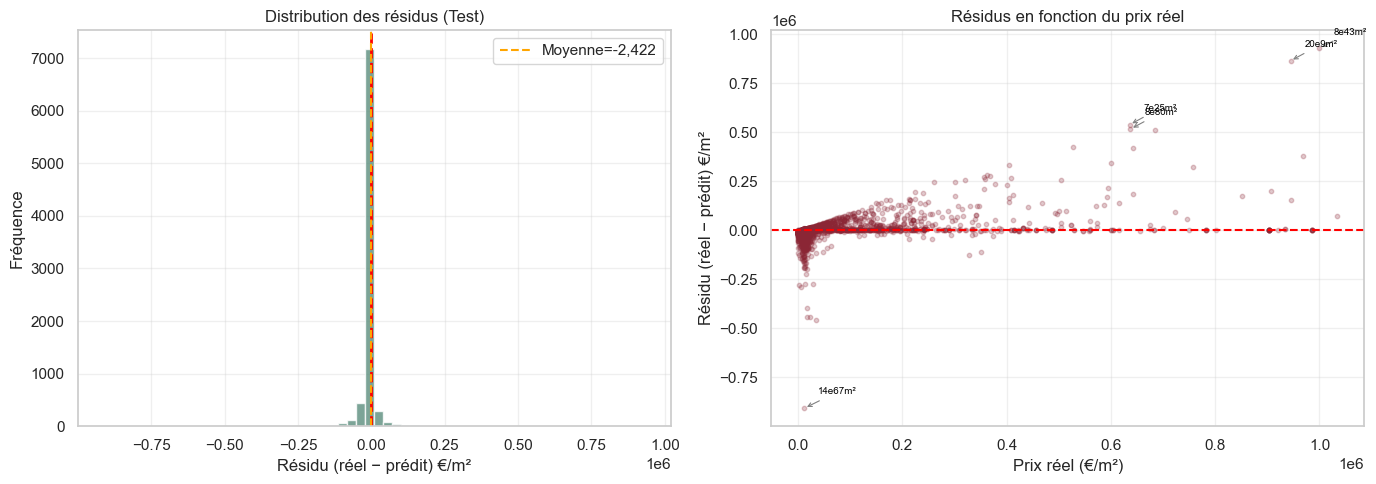


Résumé des résidus (test):
  Médiane  :     -1,068 €/m²
  Moyenne  :     -2,422 €/m²
  Std      :     34,654 €/m²
  Q5 / Q95 :    -29,810 / 13,797 €/m²


In [19]:
# ─── Analyse des Erreurs : Top 5 Pires Prédictions ───
errors_df = X_test_v2.copy()
errors_df['prix_reel']   = y_test.values
errors_df['prix_predit'] = y_pred_v2
errors_df['erreur_abs']  = (errors_df['prix_reel'] - errors_df['prix_predit']).abs()
errors_df['erreur_pct']  = (errors_df['erreur_abs'] / errors_df['prix_reel'] * 100).round(1)
errors_df['sens']        = np.where(
    errors_df['prix_predit'] > errors_df['prix_reel'], 'Sur-estimation', 'Sous-estimation'
)

top5 = errors_df.nlargest(5, 'erreur_abs').reset_index(drop=True)

print('═' * 90)
print('TOP 5 PIRES PRÉDICTIONS — Analyse des Erreurs')
print('═' * 90)
display(top5[['surface_reelle_bati', 'nombre_pieces_principales',
              'nom_commune', 'arrondissement', 'cluster_quartier',
              'prix_reel', 'prix_predit', 'erreur_abs', 'erreur_pct', 'sens']]
        .style.format({
            'surface_reelle_bati': '{:.0f} m²',
            'prix_reel':   '{:,.0f} €/m²',
            'prix_predit': '{:,.0f} €/m²',
            'erreur_abs':  '{:,.0f} €/m²',
            'erreur_pct':  '{:.1f} %'
        })
        .background_gradient(subset=['erreur_abs'], cmap='YlOrRd'))

# Distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = errors_df['prix_reel'] - errors_df['prix_predit']

axes[0].hist(residuals, bins=60, color='#5b8e7d', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', lw=2)
axes[0].axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
                label=f'Moyenne={residuals.mean():,.0f}')
axes[0].set_xlabel('Résidu (réel − prédit) €/m²')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des résidus (Test)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Résidus vs prix réel
axes[1].scatter(errors_df['prix_reel'], residuals, alpha=0.25, s=10, color='#8b2635')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Prix réel (€/m²)')
axes[1].set_ylabel('Résidu (réel − prédit) €/m²')
axes[1].set_title('Résidus en fonction du prix réel')
axes[1].grid(alpha=0.3)

# Annoter les 5 pires
for _, row in top5.iterrows():
    residual_val = row['prix_reel'] - row['prix_predit']
    axes[1].annotate(
        f"{row['arrondissement']}e{row['surface_reelle_bati']:.0f}m²",
        xy=(row['prix_reel'], residual_val),
        xytext=(10, 10), textcoords='offset points',
        fontsize=7, color='black',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

plt.tight_layout()
plt.show()

print(f'\nRésumé des résidus (test):')
print(f'  Médiane  : {residuals.median():>10,.0f} €/m²')
print(f'  Moyenne  : {residuals.mean():>10,.0f} €/m²')
print(f'  Std      : {residuals.std():>10,.0f} €/m²')
print(f'  Q5 / Q95 : {residuals.quantile(0.05):>10,.0f} / {residuals.quantile(0.95):,.0f} €/m²')

---
## K-Means Clustering — Zones Géographiques de Prix

Objectif : enrichir les features en ajoutant une variable `cluster_quartier` issue d'un K-Means sur les coordonnées GPS.

> **Anti data-leakage** : le K-Means est entraîné **uniquement sur `X_train`**, puis appliqué (`predict`) sur `X_test`.

### ✓ Bonnes pratiques respectées:

1. **Séparation Train/Test STRICTE (80/20)** 
   - Les paramètres (médiane, écart-type, catégories) sont calculés **UNIQUEMENT** sur le train
   - Le test est transformé avec les statistiques du train
   - Cela évite les fuites de données (data leakage)

2. **ColumnTransformer pour traitement différencié**
   - **Numériques**: `SimpleImputer(strategy='median')` + `StandardScaler()`
   - **Catégorielles**: `SimpleImputer(strategy='constant')` + `OneHotEncoder()`

3. **Pipeline encapsule preprocessing + modèle**
   - Workflow reproductible: fit/predict en une seule ligne
   - Évite les erreurs manuelles lors du preprocessing

4. **Gestion automatique des valeurs manquantes**
   - Pas d'exclusion manuelle de lignes (perte de données)
   - Imputation intelligente (médiane pour numériques, mode pour catégorielles)

5. **Pas de fuite de variables**
   - `valeur_fonciere` exclue (utilisée pour calculer la cible)
   - Features sélectionnées explicitement

### Résultats esperés:
- ✓ Linear Regression: baseline simple, interprétable
- ✓ Ridge: régularisation pour réduire l'overfitting
- ✓ Random Forest: capture des interactions non-linéaires
- ✓ Comparaison objectif: mêmes données, même preprocessing